In [1]:
import pandas as pd              # pandas: trabajar con tablas y datos
import numpy as np               # numpy: operaciones numéricas

In [2]:
# Cargamos el dataset desde la carpeta data
df = pd.read_csv("../data/METR-LA.csv")  # ../ sube de notebooks a la carpeta principal

print(df.shape)                          # shape devuelve (filas, columnas)

(34272, 208)


In [3]:
# Mostramos los nombres de todas las columnas
print(df.columns.tolist())  # columns obtiene las columnas; tolist() las convierte en una lista

['Unnamed: 0', '773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816', '765604', '767471', '716339', '773906', '765273', '716331', '771667', '716337', '769953', '769402', '769403', '769819', '769405', '716941', '717578', '716960', '717804', '767572', '767573', '773012', '773013', '764424', '769388', '716328', '717819', '769941', '760987', '718204', '718045', '769418', '768066', '772140', '773927', '760024', '774012', '774011', '767609', '769359', '760650', '716956', '769831', '761604', '717495', '716554', '773953', '767470', '716955', '764949', '773954', '767366', '769444', '773939', '774067', '769443', '767750', '767751', '767610', '773880', '764766', '717497', '717490', '717491', '717492', '717493', '765176', '717498', '717499', '765171', '718064', '718066', '765164', '769431', '769430', '717610', '767053', '767621', '772596', '772597', '767350', '767351', '716571', '773023', '767585', '773024', '717483', '718379', '717481', '717480', '7174

In [4]:
# Renombramos la columna de tiempo
df = df.rename(columns={"Unnamed: 0": "timestamp"})  # rename() cambia el nombre de una columna

# Convertimos la columna a formato fecha/hora
df["timestamp"] = pd.to_datetime(df["timestamp"])    # to_datetime() convierte texto en fechas

# Comprobamos el resultado
print(df["timestamp"].dtype)                         # dtype muestra el tipo de dato

datetime64[us]


In [5]:
# Reemplazamos los valores 0 por NaN
df["773869"] = df["773869"].replace(0, np.nan)  # replace() sustituye un valor por otro

In [6]:
# Contamos cuántos valores siguen siendo 0
zeros = (df["773869"] == 0).sum()  # == compara con 0; sum() cuenta los True

# Contamos cuántos valores son NaN
missing = df["773869"].isna().sum()  # isna() detecta valores faltantes; sum() los cuenta

print("Ceros:", zeros)
print("Valores faltantes:", missing)

Ceros: 0
Valores faltantes: 3843


In [7]:
# Ordenamos las filas según timestamp
df = df.sort_values("timestamp")  # sort_values() ordena el DataFrame por una columna

# Reiniciamos los índices después de ordenar
df = df.reset_index(drop=True)    # reset_index() crea índices nuevos; drop=True elimina los anteriores

#luego de esto el df deberia estar listo para el modelado, con la columna de timestamp en formato fecha/hora y los valores 0 reemplazados por NaN.

In [8]:
df.head()  # head() muestra las primeras filas del DataFrame

,timestamp,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
0,2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
1,2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2,2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
3,2012-03-01 00:15:00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
4,2012-03-01 00:20:00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [9]:
# Extraemos la hora del timestamp
df["hour"] = df["timestamp"].dt.hour  # .dt permite trabajar con fechas; .hour obtiene la hora

# Extraemos el día de la semana
df["day_of_week"] = df["timestamp"].dt.dayofweek  # dayofweek: lunes=0 ... domingo=6

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\4171055150.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour"] = df["timestamp"].dt.hour  # .dt permite trabajar con fechas; .hour obtiene la hora
C:\Users\leona\AppData\Local\Temp\ipykernel_29756\4171055150.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day_of_week"] = df["timestamp"].dt.dayofweek  # dayofweek: lunes=0 ... domingo=6


In [10]:
# Guardamos el sensor que queremos predecir
target = "773869"  # target es la variable objetivo del modelo

# Creamos la velocidad de la medición anterior
df["lag_1"] = df[target].shift(1)  # shift(1) mueve los valores una fila hacia abajo

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\4012017616.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_1"] = df[target].shift(1)  # shift(1) mueve los valores una fila hacia abajo


In [11]:
df["lag_1"]

0              NaN
1        64.375000
2        62.666667
3        64.000000
4              NaN
           ...    
34267    62.875000
34268    65.000000
34269    61.375000
34270    67.000000
34271    66.750000
Name: lag_1, Length: 34272, dtype: float64

In [12]:
df["lag_2"] = df[target].shift(2)  # shift(2) desplaza 2 filas = 10 minutos hacia atrás

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\227090847.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_2"] = df[target].shift(2)  # shift(2) desplaza 2 filas = 10 minutos hacia atrás


In [13]:
df["lag_3"] = df[target].shift(3)  # shift(3) desplaza 3 filas = 15 minutos atrás

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\3845567123.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_3"] = df[target].shift(3)  # shift(3) desplaza 3 filas = 15 minutos atrás


In [14]:
df["lag_6"] = df[target].shift(6)  # shift(6) desplaza 6 filas = 30 minutos atrás

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\3452276613.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_6"] = df[target].shift(6)  # shift(6) desplaza 6 filas = 30 minutos atrás


In [15]:
df["lag_4"] = df[target].shift(4) 
df["lag_5"] = df[target].shift(5)  

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\1424252622.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_4"] = df[target].shift(4)
C:\Users\leona\AppData\Local\Temp\ipykernel_29756\1424252622.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_5"] = df[target].shift(5)


In [16]:
df["target"] = df[target].shift(-1)  # shift(-1) mueve los valores una fila hacia arriba = 5 min futuro

C:\Users\leona\AppData\Local\Temp\ipykernel_29756\3211778218.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df[target].shift(-1)  # shift(-1) mueve los valores una fila hacia arriba = 5 min futuro


In [17]:
df = df.copy()  # copy() reorganiza internamente el DataFrame y elimina la fragmentación

In [18]:
df = df.dropna(subset=["lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6", "target"])  # dropna() elimina filas con NaN en esas columnas

In [19]:
print(df.shape)  # shape devuelve (filas, columnas)

print(df[["timestamp", "773869", "lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6", "target"]].head())
# head() muestra las primeras 5 filas de las columnas seleccionadas

(29594, 217)
             timestamp     773869      lag_1      lag_2      lag_3      lag_4  \
11 2012-03-01 00:55:00  62.250000  65.222222  63.500000  68.750000  63.625000   
12 2012-03-01 01:00:00  61.125000  62.250000  65.222222  63.500000  68.750000   
13 2012-03-01 01:05:00  58.555556  61.125000  62.250000  65.222222  63.500000   
14 2012-03-01 01:10:00  63.625000  58.555556  61.125000  62.250000  65.222222   
15 2012-03-01 01:15:00  66.777778  63.625000  58.555556  61.125000  62.250000   

        lag_5      lag_6     target  
11  66.500000  57.333333  61.125000  
12  63.625000  66.500000  58.555556  
13  68.750000  63.625000  63.625000  
14  63.500000  68.750000  66.777778  
15  65.222222  63.500000  55.875000  


In [20]:
features = ["lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6", "hour", "day_of_week"]  # Variables que usará el modelo

X = df[features]  # X contiene las variables de entrada

y = df["target"]  # y contiene lo que queremos predecir

In [21]:
split = int(len(df) * 0.8)  # len() cuenta filas; 0.8 representa el 80%

X_train = X.iloc[:split]    # iloc[:split] toma las primeras filas para entrenar
X_test = X.iloc[split:]      # iloc[split:] toma las últimas filas para probar

y_train = y.iloc[:split]    # Primer 80% de los valores objetivo
y_test = y.iloc[split:]     # Último 20% de los valores objetivo

In [22]:
print("Entrenamiento:", X_train.shape, y_train.shape)  # shape muestra filas y columnas
print("Prueba:", X_test.shape, y_test.shape)            # comprobamos el tamaño de ambos conjuntos

print("Última fecha train:", df["timestamp"].iloc[split - 1])  # Última fecha usada para entrenar
print("Primera fecha test:", df["timestamp"].iloc[split])      # Primera fecha usada para probar

Entrenamiento: (23675, 8) (23675,)
Prueba: (5919, 8) (5919,)
Última fecha train: 2012-06-04 16:00:00
Primera fecha test: 2012-06-04 16:05:00


Ahora vamos a entrenar nuestro primer modelo. Empezaremos con algo sencillo: Random Forest.

In [23]:
from sklearn.ensemble import RandomForestRegressor  # Importa el modelo Random Forest para regresión

In [24]:
model = RandomForestRegressor(
    n_estimators=100,  # Crea 100 árboles de decisión
    random_state=42    # Fija la semilla para obtener resultados reproducibles
)

In [25]:
model.fit(X_train, y_train)  # fit() entrena el modelo usando las variables X y los valores reales y

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
y_pred = model.predict(X_test)  # predict() genera predicciones usando los datos de prueba

print(y_pred[:10])              # Mostramos las primeras 10 predicciones

[59.13698413 62.58781746 60.67684524 61.0580754  62.57865079 55.74202381
 61.77414683 62.24880952 60.57734127 59.96936508]


In [27]:
from sklearn.metrics import mean_absolute_error  # Importa la métrica MAE

mae = mean_absolute_error(y_test, y_pred)       # Calcula el error absoluto promedio

print("MAE:", mae)

MAE: 2.3750706542289155


In [28]:
baseline_pred = X_test["lag_1"]  # lag_1 es la velocidad de hace 5 minutos

In [29]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)  # Calcula el error promedio del baseline

print("MAE baseline:", baseline_mae)

MAE baseline: 2.6611465096259828


Ahora vamos a añadir información espacial, usando los sensores vecinos de 773869.

El primer paso es simplemente definir los vecinos que ya encontramos:

In [30]:
neighbors = ["773906", "718204", "773927", "773953", "773916",
             "717572", "718090", "718496", "773904", "761003", "774204"]  # Sensores conectados espacialmente con 773869

In [31]:
features

['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'hour', 'day_of_week']

In [32]:
#agregamos las features de los sensores vecinos al conjunto de variables que usará el modelo
features = features + neighbors  # + agrega la lista de sensores vecinos a las features actuales

X = df[features]                 # Creamos X nuevamente con las features actualizadas

In [33]:
X

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,hour,day_of_week,773906,718204,773927,773953,773916,717572,718090,718496,773904,761003,774204
11,65.222222,63.500000,68.750000,63.625000,66.500000,57.333333,0,3,62.750000,57.750000,61.000000,53.250000,61.250000,60.875000,44.750000,57.875000,56.250000,62.000000,60.000000
12,62.250000,65.222222,63.500000,68.750000,63.625000,66.500000,1,3,63.375000,59.500000,64.375000,63.750000,68.375000,57.750000,52.500000,61.500000,58.500000,63.375000,53.625000
13,61.125000,62.250000,65.222222,63.500000,68.750000,63.625000,1,3,68.333333,63.000000,63.333333,54.555556,66.555556,63.333333,49.888889,61.111111,60.888889,64.222222,61.333333
14,58.555556,61.125000,62.250000,65.222222,63.500000,68.750000,1,3,62.000000,65.875000,66.750000,61.625000,66.875000,65.875000,53.375000,59.875000,63.750000,67.250000,59.000000
15,63.625000,58.555556,61.125000,62.250000,65.222222,63.500000,1,3,67.444444,65.888889,63.444444,59.777778,66.111111,64.111111,50.888889,64.888889,60.666667,66.888889,62.777778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34266,67.625000,63.111111,67.428571,66.375000,65.555556,66.375000,23,2,67.125000,66.000000,64.625000,60.875000,67.125000,63.375000,58.625000,61.250000,62.000000,64.500000,64.500000
34267,62.875000,67.625000,63.111111,67.428571,66.375000,65.555556,23,2,65.222222,66.222222,66.111111,62.666667,67.888889,65.222222,56.222222,65.222222,63.000000,66.888889,65.111111
34268,65.000000,62.875000,67.625000,63.111111,67.428571,66.375000,23,2,66.250000,66.375000,67.375000,62.500000,68.250000,65.750000,57.875000,64.625000,64.750000,66.375000,60.125000
34269,61.375000,65.000000,62.875000,67.625000,63.111111,67.428571,23,2,66.444444,63.333333,65.333333,59.888889,65.777778,63.333333,54.888889,61.222222,64.222222,67.222222,64.333333


In [34]:
df[neighbors].eq(0).sum()  # eq(0) compara cada valor con 0; sum() cuenta los 0 de cada sensor

773906     499
718204     740
773927    1033
773953      52
773916     497
717572      34
718090     744
718496    1449
773904     478
761003      46
774204    1412
dtype: int64

In [35]:
df[neighbors] = df[neighbors].replace(0, np.nan)  # replace() cambia los 0 por NaN en todos los vecinos

In [36]:
df[neighbors].isna().sum()  # isna() detecta NaN; sum() cuenta los faltantes de cada sensor

773906     499
718204     740
773927    1033
773953      52
773916     497
717572      34
718090     744
718496    1449
773904     478
761003      46
774204    1412
dtype: int64

In [37]:
df = df.dropna(subset=neighbors)  # dropna() elimina filas que tengan NaN en cualquiera de los vecinos

In [38]:
print(df.shape)  # shape muestra (filas, columnas)

(25546, 217)


In [39]:
X = df[features]  # Selecciona nuevamente todas las variables que usará el modelo
y = df["target"]  # Selecciona nuevamente el valor que queremos predecir

In [40]:
split = int(len(df) * 0.8)  # Calcula dónde termina el 80% de los datos

X_train = X.iloc[:split]     # Primer 80% para entrenar
X_test = X.iloc[split:]      # Último 20% para probar

y_train = y.iloc[:split]     # Targets del entrenamiento
y_test = y.iloc[split:]      # Targets de prueba

In [41]:
#Ahora entrenamos el mismo Random Forest, pero esta vez con los sensores vecinos incluidos:
model_neighbors = RandomForestRegressor(
    n_estimators=100,  # Crea 100 árboles de decisión
    random_state=42    # Mantiene los resultados reproducibles
)

model_neighbors.fit(X_train, y_train)  # fit() entrena el modelo con los datos

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [42]:
y_pred_neighbors = model_neighbors.predict(X_test)  # predict() genera predicciones para los datos de prueba

In [43]:
mae_neighbors = mean_absolute_error(y_test, y_pred_neighbors)  # Calcula el error promedio del modelo

print("MAE con vecinos:", mae_neighbors)                       # Muestra el resultado

MAE con vecinos: 2.0264712631627995


Baseline              2.661 km/h
Random Forest          2.375 km/h
Random Forest + vecinos 2.026 km/h

Pasamos de 2.375 → 2.026 km/h, una mejora de aproximadamente 14.7% respecto al Random Forest anterior.

Vamos a ver qué variables fueron más importantes para el Random Forest.

In [44]:
importance = pd.Series(model_neighbors.feature_importances_, index=features)  # Crea una serie con la importancia de cada feature

In [45]:
importance.sort_values(ascending=False)  # sort_values() ordena; ascending=False pone la mayor primero

761003         0.803993
lag_1          0.076094
hour           0.013377
lag_2          0.012205
718204         0.008373
773916         0.008258
773953         0.008221
773904         0.008141
lag_4          0.006690
773906         0.006503
718090         0.006280
774204         0.006013
lag_3          0.005766
lag_5          0.005586
773927         0.005562
lag_6          0.005483
717572         0.005250
718496         0.004372
day_of_week    0.003833
dtype: float64

importancia del Random Forest ≠ correlación. La correlación mide relación lineal entre dos variables; feature_importances_ mide cuánto contribuye cada variable a las decisiones de los árboles.

In [46]:
df[["773869", "761003"]].corr()  # corr() calcula la correlación entre las dos series

,773869,761003
773869,1.000000,0.912946
761003,0.912946,1.000000


In [47]:
#vamos a ver q tan cerca esta el sensor 761003 del sensor 773869 en el espacio de la matriz de adyacencia
import pickle  # pickle permite abrir archivos .pkl

In [48]:
with open("../data/adj_mx_METR-LA.pkl", "rb") as f:  # open() abre el .pkl en modo binario
    adj = pickle.load(f, encoding="latin1")            # encoding permite leer el pickle antiguo

In [49]:
sensor_id_to_ind = adj[1]  # adj[1] es el diccionario sensor → índice

In [50]:
print(sensor_id_to_ind["773869"])  # Busca el índice de 773869
print(sensor_id_to_ind["761003"])  # Busca el índice de 761003

0
145


In [51]:
print(adj[2][0, 145])  # adj[2] es la matriz; [0,145] busca la conexión entre ambos sensores

#un valor mayor q 0 indica q hay una conexión entre ambos sensores, mientras q un valor de 0 indica q no hay conexión.

0.87776124


In [52]:
#Ahora queremos comprobar si 761003 unos minutos antes predice mejor a 773869 que su valor actual.



#correlacion
df["761003_lag1"] = df["761003"].shift(1)  # shift(1) mueve 761003 una fila = 5 min hacia atrás

print(df[["773869", "761003_lag1"]].corr())  # corr() calcula la correlación entre ambas series

               773869  761003_lag1
773869       1.000000     0.899002
761003_lag1  0.899002     1.000000


In [53]:
df["761003_lag2"] = df["761003"].shift(2)  # shift(2) desplaza 2 filas = 10 minutos atrás

print(df[["773869", "761003_lag2"]].corr())  # corr() calcula la correlación entre ambas series

              773869  761003_lag2
773869       1.00000      0.87434
761003_lag2  0.87434      1.00000


In [54]:
df["761003_lag3"] = df["761003"].shift(3)  # shift(3) mueve 3 filas = 15 minutos atrás

print(df[["773869", "761003_lag3"]].corr())  # corr() calcula la correlación entre ambas series

               773869  761003_lag3
773869       1.000000     0.844842
761003_lag3  0.844842     1.000000


¿Qué pasa si usamos solo 761003 como sensor vecino, en lugar de los 11 vecinos?

In [55]:
features_base = ["lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6", "hour", "day_of_week"]  # Variables temporales originales
features_761003 = features_base + ["761003"]  # Une las features originales con solo el sensor 761003

In [56]:
X = df[features_761003]  # Selecciona las variables originales + 761003

In [57]:
X

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,hour,day_of_week,761003
11,65.222222,63.500000,68.750000,63.625000,66.500000,57.333333,0,3,62.000000
12,62.250000,65.222222,63.500000,68.750000,63.625000,66.500000,1,3,63.375000
13,61.125000,62.250000,65.222222,63.500000,68.750000,63.625000,1,3,64.222222
14,58.555556,61.125000,62.250000,65.222222,63.500000,68.750000,1,3,67.250000
15,63.625000,58.555556,61.125000,62.250000,65.222222,63.500000,1,3,66.888889
...,...,...,...,...,...,...,...,...,...
34266,67.625000,63.111111,67.428571,66.375000,65.555556,66.375000,23,2,64.500000
34267,62.875000,67.625000,63.111111,67.428571,66.375000,65.555556,23,2,66.888889
34268,65.000000,62.875000,67.625000,63.111111,67.428571,66.375000,23,2,66.375000
34269,61.375000,65.000000,62.875000,67.625000,63.111111,67.428571,23,2,67.222222


In [58]:
split = int(len(df) * 0.8)  # Calcula el punto donde termina el 80%

X_train = X.iloc[:split]     # Primer 80% para entrenamiento
X_test = X.iloc[split:]      # Último 20% para prueba

y_train = y.iloc[:split]     # Targets del entrenamiento
y_test = y.iloc[split:]      # Targets de prueba

In [59]:
model_761003 = RandomForestRegressor(
    n_estimators=100,  # Crea 100 árboles de decisión
    random_state=42    # Hace reproducible el entrenamiento
)

model_761003.fit(X_train, y_train)  # fit() entrena el modelo

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [60]:
y_pred_761003 = model_761003.predict(X_test)  # predict() genera las predicciones del conjunto de prueba

In [61]:
mae_761003 = mean_absolute_error(y_test, y_pred_761003)  # Calcula el error promedio del modelo

print("MAE solo 761003:", mae_761003)                    # Muestra el resultado

MAE solo 761003: 2.076772899388066


In [62]:
improvement = (2.6611465096259828 - 2.0264712631627995) / 2.6611465096259828 * 100  # Calcula el % de reducción del error

print("Mejora total:", improvement, "%")  # Muestra cuánto mejoramos respecto al baseline

Mejora total: 23.849692009343194 %


In [63]:
# el Random Forest + los 11 sensores vecinos mejora 23% respecto al baseline, es mi mejor modelo 

In [64]:
#RMSE para ver los errores grandes y no solo el promedio de los errores absolutos que nos da el MAE

from sklearn.metrics import mean_squared_error  # Importa la métrica MSE

rmse = mean_squared_error(y_test, y_pred_neighbors) ** 0.5  # MSE calcula el error cuadrático; **0.5 obtiene la raíz

print("RMSE:", rmse)  # Muestra el error promedio dando más peso a errores grandes

RMSE: 4.1642136632523705


In [65]:
errors = abs(y_test - y_pred_neighbors)  # abs() convierte cada error en positivo

print("Error máximo:", errors.max())  # max() obtiene el error más grande

Error máximo: 59.284583333333345


In [66]:
print("Errores > 10:", (errors > 10).sum())  # > 10 crea una condición; sum() cuenta cuántos errores la cumplen

Errores > 10: 135


In [67]:
worst = errors.sort_values(ascending=False).head(10)  # Ordena errores de mayor a menor y toma los 10 peores

print(df.loc[worst.index, ["timestamp", "773869", "target"]])  # Muestra fecha, velocidad actual y velocidad objetivo

                timestamp     773869     target
32687 2012-06-22 11:55:00  45.500000   4.750000
32925 2012-06-23 07:45:00  62.111111  12.000000
31942 2012-06-19 21:50:00  42.750000  18.777778
28727 2012-06-08 17:55:00  59.375000  65.888889
28726 2012-06-08 17:50:00  16.750000  59.375000
33633 2012-06-25 18:45:00  34.250000  66.666667
30710 2012-06-15 15:10:00  44.333333  63.000000
32918 2012-06-23 07:10:00  67.333333  66.888889
32917 2012-06-23 07:05:00  63.000000  67.333333
32919 2012-06-23 07:15:00  66.888889  64.500000


In [68]:
print(pd.DataFrame({                         # pd.DataFrame() crea una tabla
    "real": y_test.loc[worst.index].values,  # .loc[] busca las filas por sus índices
    "prediccion": y_pred_neighbors[errors.index.get_indexer(worst.index)]  # get_indexer() convierte índices en posiciones
}))

        real  prediccion
0   4.750000   64.034583
1  12.000000   65.385595
2  18.777778   67.045853
3  65.888889   17.767222
4  59.375000   14.213056
5  66.666667   25.962044
6  63.000000   23.155377
7  66.888889   27.444563
8  67.333333   29.994167
9  64.500000   28.093790


In [69]:
print(df.loc[32687, ["773869"] + neighbors])  # loc[] busca esa fila; mostramos el sensor objetivo y sus vecinos

773869    45.500000
773906    65.750000
718204    66.875000
773927    67.250000
773953    61.375000
773916    67.375000
717572    60.375000
718090    56.375000
718496    62.375000
773904    64.250000
761003    68.428571
774204    59.625000
Name: 32687, dtype: float64


In [70]:
df["delta_773869"] = df["773869"].diff()  # diff() calcula cuánto cambió la velocidad respecto a la fila anterior

print(df["delta_773869"].abs().max())  # abs() obtiene el cambio en valor absoluto; max() busca el mayor

62.125


In [71]:
print((df["delta_773869"].abs() > 20).sum())  # Cuenta cambios mayores a 20 km/h en 5 minutos

205


In [72]:
df["delta_761003"] = df["761003"].diff()  # diff() calcula el cambio de 761003 respecto a los 5 minutos anteriores

In [73]:
print(df[["delta_773869", "delta_761003"]].corr())  # corr() mide qué tan relacionados están ambos cambios

              delta_773869  delta_761003
delta_773869      1.000000      0.355042
delta_761003      0.355042      1.000000


In [74]:
df["target_delta"] = df["target"] - df["773869"]  # Calcula cuánto cambiará 773869 durante los próximos 5 minutos

In [75]:
df["target_delta"]

11       -1.125000
12       -2.569444
13        5.069444
14        3.152778
15      -10.902778
           ...    
34266     2.125000
34267    -3.625000
34268     5.625000
34269    -0.250000
34270    -1.638889
Name: target_delta, Length: 25546, dtype: float64

In [76]:
df["delta_773869"]

11            NaN
12      -1.125000
13      -2.569444
14       5.069444
15       3.152778
           ...   
34266   -4.750000
34267    2.125000
34268   -3.625000
34269    5.625000
34270   -0.250000
Name: delta_773869, Length: 25546, dtype: float64

In [77]:
print(df[["delta_773869", "target_delta"]].corr())  # Compara el cambio actual con el cambio futuro

              delta_773869  target_delta
delta_773869      1.000000     -0.091274
target_delta     -0.091274      1.000000


Velocidad 773869 ↔ 761003       0.913  alto
Cambio 773869 ↔ cambio 761003   0.355  medio bajo
Cambio pasado ↔ cambio futuro   -0.091 bajisimo

In [78]:
results = pd.DataFrame({
    "timestamp": df.loc[y_test.index, "timestamp"].values,
    "real": y_test.values,
    "prediccion": y_pred_neighbors
})

results.head()

,timestamp,real,prediccion
0,2012-06-06 04:00:00,58.000000,56.964504
1,2012-06-06 04:05:00,58.125000,59.156655
2,2012-06-06 04:10:00,59.125000,56.765337
3,2012-06-06 04:15:00,62.888889,58.662107
4,2012-06-06 04:20:00,59.625000,61.670429


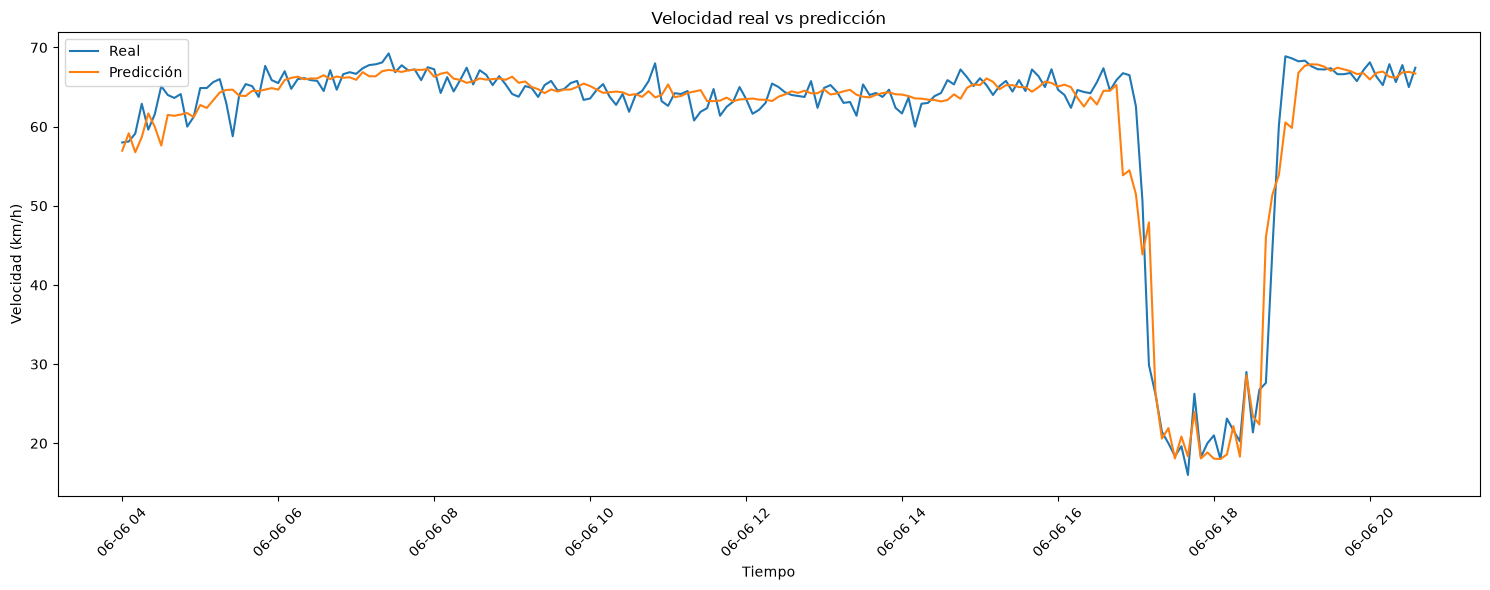

In [79]:
import matplotlib.pyplot as plt  # Importa la librería para crear gráficos

plt.figure(figsize=(15, 6))  # Crea una figura de 15 pulgadas de ancho y 6 de alto

plt.plot(
    results["timestamp"].iloc[:200],  # Usa los primeros 200 timestamps
    results["real"].iloc[:200],       # Usa los primeros 200 valores reales
    label="Real"                      # Nombre de esta línea en la leyenda
)

plt.plot(
    results["timestamp"].iloc[:200],      # Usa los mismos primeros 200 timestamps
    results["prediccion"].iloc[:200],     # Usa las primeras 200 predicciones
    label="Predicción"                    # Nombre de esta línea en la leyenda
)

plt.xlabel("Tiempo")              # Nombre del eje X
plt.ylabel("Velocidad (km/h)")    # Nombre del eje Y

plt.title("Velocidad real vs predicción")  # Título del gráfico

plt.legend()  # Muestra la leyenda para distinguir ambas líneas

plt.xticks(rotation=45)  # Gira las fechas para que sean más fáciles de leer

plt.tight_layout()  # Ajusta automáticamente los espacios del gráfico

plt.show()  # Muestra el gráfico

In [80]:
results["error"] = abs(results["real"] - results["prediccion"])  # Calcula el error absoluto de cada predicción

worst_position = results["error"].idxmax()  # Busca la posición del error más grande

print(results.loc[worst_position])  # Muestra la fila correspondiente al peor error

timestamp     2012-06-22 11:55:00
real                         4.75
prediccion              64.034583
error                   59.284583
Name: 3713, dtype: object


In [81]:
start = worst_position - 20  # Empieza 20 observaciones antes del peor error

end = worst_position + 21    # Termina 20 observaciones después del peor error

worst_results = results.iloc[start:end]  # Selecciona ese intervalo usando posiciones

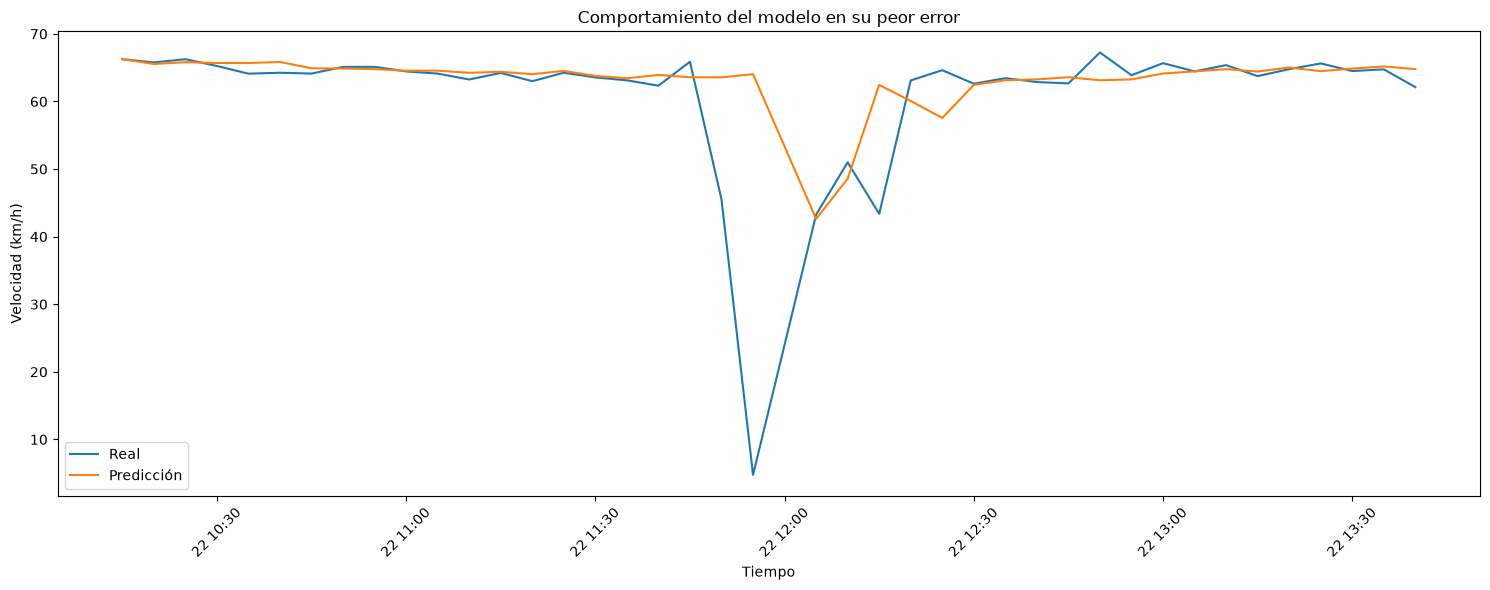

In [82]:
plt.figure(figsize=(15, 6))  # Crea una figura de 15 x 6 pulgadas

plt.plot(
    worst_results["timestamp"],   # Eje X: tiempo
    worst_results["real"],        # Valores reales
    label="Real"                  # Nombre de la línea real
)

plt.plot(
    worst_results["timestamp"],   # Mismos timestamps
    worst_results["prediccion"],  # Predicciones del modelo
    label="Predicción"             # Nombre de la línea de predicción
)

plt.xlabel("Tiempo")              # Etiqueta del eje X
plt.ylabel("Velocidad (km/h)")    # Etiqueta del eje Y

plt.title("Comportamiento del modelo en su peor error")  # Título

plt.legend()  # Muestra la leyenda

plt.xticks(rotation=45)  # Gira las fechas para facilitar su lectura

plt.tight_layout()  # Ajusta automáticamente los espacios

plt.show()  # Muestra el gráfico

In [83]:
df["diff_761003"] = df["773869"] - df["761003"]  # Calcula la diferencia entre el sensor objetivo y 761003

In [84]:
print(df[["diff_761003", "target_delta"]].corr())  # Compara la diferencia actual con el cambio de velocidad futuro

              diff_761003  target_delta
diff_761003      1.000000     -0.276726
target_delta    -0.276726      1.000000


In [85]:
df["rolling_mean_3"] = df["773869"].rolling(3).mean()  # Calcula el promedio de las últimas 3 mediciones (15 min)

In [86]:
df

,timestamp,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,lag_5,target,761003_lag1,761003_lag2,761003_lag3,delta_773869,delta_761003,target_delta,diff_761003,rolling_mean_3
11,2012-03-01 00:55:00,62.250000,67.750000,66.875000,60.000000,64.750000,66.285714,61.250000,63.250000,52.625000,...,66.500000,61.125000,NaN,NaN,NaN,NaN,NaN,-1.125000,0.250000,NaN
12,2012-03-01 01:00:00,61.125000,67.000000,58.500000,62.250000,66.375000,67.500000,63.125000,68.375000,56.000000,...,63.625000,58.555556,62.000000,NaN,NaN,-1.125000,1.375000,-2.569444,-2.250000,NaN
13,2012-03-01 01:05:00,58.555556,62.666667,65.777778,59.777778,66.888889,64.333333,66.111111,65.666667,59.222222,...,68.750000,63.625000,63.375000,62.000000,NaN,-2.569444,0.847222,5.069444,-5.666667,60.643519
14,2012-03-01 01:10:00,63.625000,67.000000,55.000000,59.125000,67.625000,67.000000,65.125000,62.375000,59.875000,...,63.500000,66.777778,64.222222,63.375000,62.000000,5.069444,3.027778,3.152778,-3.625000,61.101852
15,2012-03-01 01:15:00,66.777778,65.555556,68.111111,59.888889,61.333333,68.333333,59.666667,66.888889,57.000000,...,65.222222,55.875000,67.250000,64.222222,63.375000,3.152778,-0.361111,-10.902778,-0.111111,62.986111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34266,2012-06-27 23:30:00,62.875000,65.875000,68.250000,62.750000,0.000000,57.500000,63.625000,62.500000,57.875000,...,65.555556,65.000000,69.000000,65.666667,67.142857,-4.750000,-4.500000,2.125000,-1.625000,64.537037
34267,2012-06-27 23:35:00,65.000000,65.888889,68.555556,61.666667,0.000000,54.555556,62.444444,63.333333,59.222222,...,66.375000,61.375000,64.500000,69.000000,65.666667,2.125000,2.388889,-3.625000,-1.888889,65.166667
34268,2012-06-27 23:40:00,61.375000,65.625000,66.500000,62.750000,0.000000,50.500000,62.000000,67.000000,65.250000,...,67.428571,67.000000,66.888889,64.500000,69.000000,-3.625000,-0.513889,5.625000,-5.000000,63.083333
34269,2012-06-27 23:45:00,67.000000,59.666667,69.555556,61.000000,0.000000,44.777778,64.222222,63.777778,59.777778,...,63.111111,66.750000,66.375000,66.888889,64.500000,5.625000,0.847222,-0.250000,-0.222222,64.458333


In [87]:
df["rolling_std_3"] = df["773869"].rolling(3).std()  # Calcula cuánto varió la velocidad durante las últimas 3 mediciones

In [88]:
print(df[["rolling_mean_3", "rolling_std_3"]].isna().sum())  # Cuenta los valores faltantes de las nuevas features

rolling_mean_3    11
rolling_std_3     11
dtype: int64


In [89]:
df = df.dropna(subset=["rolling_mean_3", "rolling_std_3"])  # Elimina las filas donde las nuevas features no pudieron calcularse

In [90]:
print(
    df.loc[
        df["timestamp"] == "2012-06-22 11:55:00",  # Busca exactamente el momento del peor error
        ["773869", "rolling_mean_3", "rolling_std_3", "target"]  # Muestra las variables que nos interesan
    ]
)

       773869  rolling_mean_3  rolling_std_3  target
32687    45.5       57.902778      10.886116    4.75


In [91]:
print(
    df[["rolling_mean_3", "rolling_std_3", "target_delta"]].corr()
)  # Comprueba si las nuevas features tienen relación con el cambio futuro

                rolling_mean_3  rolling_std_3  target_delta
rolling_mean_3        1.000000      -0.356779     -0.143030
rolling_std_3        -0.356779       1.000000      0.060747
target_delta         -0.143030       0.060747      1.000000


In [92]:
features_rolling = features + ["rolling_mean_3", "rolling_std_3"]  # Añade las dos nuevas features a las originales

In [93]:
X = df[features_rolling]  # Selecciona las features originales + las dos nuevas

¿Las ventanas temporales realmente mejoran nuestro 2.026 de MAE?

In [94]:
y = df["target"]  # Vuelve a crear el target usando el DataFrame actualizado

In [95]:
split = int(len(df) * 0.8)  # Calcula el punto donde termina el 80% de los datos

X_train = X.iloc[:split]     # Primer 80% para entrenamiento
X_test = X.iloc[split:]      # Último 20% para prueba

y_train = y.iloc[:split]     # Targets del entrenamiento
y_test = y.iloc[split:]      # Targets de prueba

In [96]:
model_rolling = RandomForestRegressor(
    n_estimators=100,  # Crea 100 árboles de decisión
    random_state=42    # Hace reproducible el entrenamiento
)


In [97]:
model_rolling.fit(X_train, y_train)  # Entrena el modelo con las nuevas features

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [98]:
y_pred_rolling = model_rolling.predict(X_test)  # Genera las predicciones sobre los datos de prueba

In [99]:
mae_rolling = mean_absolute_error(y_test, y_pred_rolling)  # Calcula el MAE del nuevo modelo

print("MAE con rolling:", mae_rolling)  # Muestra el MAE del modelo con las nuevas features

print("MAE modelo anterior:", 2.0264712631627995)  # Nuestro mejor MAE antes de añadir rolling

MAE con rolling: 1.927182956943629
MAE modelo anterior: 2.0264712631627995


In [100]:
importance_rolling = pd.Series(
    model_rolling.feature_importances_,  # Obtiene la importancia de cada feature del nuevo Random Forest
    index=features_rolling               # Asocia cada importancia con el nombre de su feature
)

print(importance_rolling.sort_values(ascending=False))  # Ordena las features de mayor a menor importancia

761003            0.651971
rolling_mean_3    0.246302
hour              0.012431
rolling_std_3     0.009008
773904            0.007915
718204            0.006858
lag_2             0.006334
773916            0.006239
lag_4             0.005247
773953            0.005176
773927            0.004599
773906            0.004555
718090            0.004359
lag_6             0.004306
lag_3             0.004254
lag_5             0.004100
774204            0.003740
lag_1             0.003664
717572            0.003608
718496            0.003229
day_of_week       0.002105
dtype: float64


In [101]:
features_mean_only = [  # Crea una nueva lista de features
    feature for feature in features_rolling  # Recorre todas las features actuales
    if feature != "rolling_std_3"  # Mantiene todas excepto rolling_std_3
]

In [102]:
X_mean_only = df[features_mean_only]  # Selecciona las columnas sin rolling_std_3

In [103]:
split = int(len(df) * 0.8)  # Calcula el punto del 80%

X_train_mean = X_mean_only.iloc[:split]  # Primer 80% para entrenamiento
X_test_mean = X_mean_only.iloc[split:]   # Último 20% para prueba

In [104]:
model_mean_only = RandomForestRegressor(
    n_estimators=100,  # Crea 100 árboles
    random_state=42    # Mantiene el experimento reproducible
)

model_mean_only.fit(X_train_mean, y_train)  # Entrena usando solo rolling_mean_3

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [105]:
y_pred_mean = model_mean_only.predict(X_test_mean)  # Genera las predicciones usando el conjunto de prueba

In [106]:
mae_mean_only = mean_absolute_error(
    y_test,        # Valores reales
    y_pred_mean    # Predicciones del nuevo modelo
)

print("MAE solo rolling_mean_3:", mae_mean_only)  # Muestra el error promedio

MAE solo rolling_mean_3: 1.9314408709179125


In [107]:
df["rolling_mean_6"] = df["773869"].rolling(6).mean()  # Calcula el promedio de las últimas 6 mediciones (30 minutos)

df["rolling_std_6"] = df["773869"].rolling(6).std()  # Calcula la desviación estándar de las últimas 6 mediciones (30 minutos)

In [108]:
print(
    df[["rolling_mean_6", "rolling_std_6"]].isna().sum()
)  # Cuenta los valores faltantes de cada nueva feature

rolling_mean_6    5
rolling_std_6     5
dtype: int64


In [109]:
df6 = df.dropna(
    subset=["rolling_mean_6", "rolling_std_6"]
).copy()  # Eliminamos solamente las 5 primeras filas que no tienen rolling de 30 minutos
#.copy es para que no se genere un SettingWithCopyWarning al modificar df6 más adelante. Esto asegura que df6 sea una copia independiente de df y evita problemas al trabajar con subconjuntos del DataFrame original.

In [110]:
y6 = df6["target"]  # Volvemos a construir el target usando exactamente las filas de df6

In [111]:
X6 = df6[features + ["rolling_mean_6", "rolling_std_6"]]  # Usamos las features anteriores + las dos nuevas features

In [112]:
split = int(len(df6) * 0.8)  # Reservamos el 80% inicial para entrenamiento

In [113]:
X_train_6 = X6.iloc[:split]  # Primer 80% de las features para entrenar
X_test_6 = X6.iloc[split:]  # Último 20% para probar

In [114]:
y_train_6 = y6.iloc[:split]  # Target correspondiente al entrenamiento
y_test_6 = y6.iloc[split:]  # Target correspondiente a la prueba

In [115]:
model_rolling_6 = RandomForestRegressor(
    n_estimators=100,  # Usamos 100 árboles como en los experimentos anteriores
    random_state=42  # Fijamos la semilla para poder comparar resultados
)

In [116]:
model_rolling_6.fit(
    X_train_6,  # Datos de entrenamiento
    y_train_6  # Valores reales de velocidad
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [117]:
y_pred_6 = model_rolling_6.predict(
    X_test_6  # Generamos predicciones sobre el conjunto de prueba
)

In [118]:
mae_6 = mean_absolute_error(
    y_test_6,  # Valores reales
    y_pred_6  # Predicciones del modelo
)

In [119]:
print("MAE rolling 6:", mae_6)  # Mostramos el error con una ventana de 30 minutos

MAE rolling 6: 1.968543319717233


In [120]:
# ============================================================
# ROLLING WINDOW DE 2 MEDICIONES = 10 MINUTOS
# ============================================================

df2 = df.copy()  # Creamos una copia para no modificar el DataFrame original


# ------------------------------------------------------------
# 1. Creamos las nuevas features
# ------------------------------------------------------------

df2["rolling_mean_2"] = (
    df2["773869"].rolling(2).mean()
)  # Promedio de las últimas 2 mediciones = últimos 10 minutos


df2["rolling_std_2"] = (
    df2["773869"].rolling(2).std()
)  # Desviación estándar de las últimas 2 mediciones


# ------------------------------------------------------------
# 2. Revisamos los valores NaN
# ------------------------------------------------------------

print(
    df2[["rolling_mean_2", "rolling_std_2"]].isna().sum()
)  # Deberíamos tener 1 NaN en cada feature


# ------------------------------------------------------------
# 3. Eliminamos las filas que no tienen rolling calculado
# ------------------------------------------------------------

df2 = df2.dropna(
    subset=["rolling_mean_2", "rolling_std_2"]
).copy()  # Eliminamos solamente la primera fila


# ------------------------------------------------------------
# 4. Creamos nuevamente el target
# ------------------------------------------------------------

y2 = df2["target"]  # Target correspondiente exactamente a las filas de df2


# ------------------------------------------------------------
# 5. Creamos las features
# ------------------------------------------------------------

features_rolling_2 = (
    features
    + ["rolling_mean_2", "rolling_std_2"]
)  # Features anteriores + rolling de 10 minutos


X2 = df2[features_rolling_2]  # Construimos la matriz de features


# ------------------------------------------------------------
# 6. Split temporal 80/20
# ------------------------------------------------------------

split = int(len(df2) * 0.8)  # 80% para entrenamiento y 20% para prueba


X_train_2 = X2.iloc[:split]  # Primer 80% de las features
X_test_2 = X2.iloc[split:]  # Último 20% de las features


y_train_2 = y2.iloc[:split]  # Target del entrenamiento
y_test_2 = y2.iloc[split:]  # Target de prueba


# ------------------------------------------------------------
# 7. Creamos el Random Forest
# ------------------------------------------------------------

model_rolling_2 = RandomForestRegressor(
    n_estimators=100,  # 100 árboles
    random_state=42  # Misma semilla para comparar justamente
)


# ------------------------------------------------------------
# 8. Entrenamos
# ------------------------------------------------------------

model_rolling_2.fit(
    X_train_2,  # Features de entrenamiento
    y_train_2  # Valores reales de entrenamiento
)


# ------------------------------------------------------------
# 9. Generamos predicciones
# ------------------------------------------------------------

y_pred_2 = model_rolling_2.predict(
    X_test_2  # Features del conjunto de prueba
)


# ------------------------------------------------------------
# 10. Calculamos MAE
# ------------------------------------------------------------

mae_2 = mean_absolute_error(
    y_test_2,  # Valores reales
    y_pred_2  # Predicciones del modelo
)


# ------------------------------------------------------------
# 11. Mostramos el resultado
# ------------------------------------------------------------

print(
    "MAE rolling 2:", mae_2
)  # Error absoluto medio usando una ventana de 10 minutos

rolling_mean_2    1
rolling_std_2     1
dtype: int64
MAE rolling 2: 1.8692445538492142


In [121]:
features_mean_2 = [
    feature
    for feature in features_rolling_2
    if feature != "rolling_std_2"
]

X_mean_2 = df2[features_mean_2]

X_train_mean_2 = X_mean_2.iloc[:split]
X_test_mean_2 = X_mean_2.iloc[split:]

model_mean_2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_mean_2.fit(
    X_train_mean_2,
    y_train_2
)

y_pred_mean_2 = model_mean_2.predict(
    X_test_mean_2
)

mae_mean_2 = mean_absolute_error(
    y_test_2,
    y_pred_mean_2
)

print("MAE rolling 2 mean only:", mae_mean_2)

MAE rolling 2 mean only: 1.8725237224972884


In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# 1. MAE
# ------------------------------------------------------------

mae_2 = mean_absolute_error(
    y_test_2,
    y_pred_2
)  # Error absoluto medio


# ------------------------------------------------------------
# 2. RMSE
# ------------------------------------------------------------

rmse_2 = np.sqrt(
    mean_squared_error(
        y_test_2,
        y_pred_2
    )
)  # Penaliza mucho más los errores grandes


# ------------------------------------------------------------
# 3. Errores individuales
# ------------------------------------------------------------

errors_2 = np.abs(
    y_test_2.values - y_pred_2
)  # Error absoluto de cada predicción


# ------------------------------------------------------------
# 4. Cuántos errores superan 10 km/h
# ------------------------------------------------------------

errors_over_10_2 = (
    errors_2 > 10
).sum()  # Cuenta errores mayores a 10 km/h


# ------------------------------------------------------------
# 5. Error máximo
# ------------------------------------------------------------

max_error_2 = errors_2.max()  # Encuentra el peor error del modelo


# ------------------------------------------------------------
# 6. Mostramos todo
# ------------------------------------------------------------

print("MAE:", mae_2)
print("RMSE:", rmse_2)
print("Errores > 10 km/h:", errors_over_10_2)
print("Error máximo:", max_error_2)

MAE: 1.8692445538492142
RMSE: 3.6474835045448155
Errores > 10 km/h: 120
Error máximo: 52.109146825396806


In [123]:
results_2 = pd.DataFrame({
    "timestamp": df2.loc[y_test_2.index, "timestamp"].values,
    "real": y_test_2.values,
    "prediccion": y_pred_2,
    "error": np.abs(y_test_2.values - y_pred_2)
})  # Creamos una tabla con cada predicción y su error


worst_10_2 = results_2.sort_values(
    "error",
    ascending=False
).head(10)  # Ordenamos de mayor a menor error y tomamos los 10 peores


print(worst_10_2)

               timestamp       real  prediccion      error
3931 2012-06-23 07:45:00  12.000000   64.109147  52.109147
3710 2012-06-22 11:55:00   4.750000   56.714325  51.964325
706  2012-06-08 17:50:00  59.375000   14.309325  45.065675
707  2012-06-08 17:55:00  65.888889   27.801317  38.087571
4478 2012-06-25 18:45:00  66.666667   30.379488  36.287179
2124 2012-06-14 20:20:00  68.222222   32.567004  35.655218
4996 2012-06-27 13:55:00  31.111111   65.061647  33.950536
2264 2012-06-15 15:10:00  63.000000   29.257897  33.742103
2533 2012-06-17 11:50:00  28.777778   61.955694  33.177917
3929 2012-06-23 07:35:00  67.500000   36.416508  31.083492


In [124]:
df2["delta_1"] = (
    df2["773869"] - df2["lag_1"]
)  # Calculamos cuánto cambió la velocidad respecto a hace 5 minutos


features_delta = (
    features_rolling_2
    +
    ["delta_1"]
)  # Añadimos la nueva feature al conjunto que ya nos daba el mejor resultado


X_delta = df2[features_delta]  # Construimos las features del nuevo experimento


X_train_delta = X_delta.iloc[:split]  # Primer 80% para entrenamiento
X_test_delta = X_delta.iloc[split:]  # Último 20% para prueba


model_delta = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)  # Mismo Random Forest para que la comparación sea justa


model_delta.fit(
    X_train_delta,
    y_train_2
)  # Entrenamos el modelo


y_pred_delta = model_delta.predict(
    X_test_delta
)  # Generamos las predicciones


mae_delta = mean_absolute_error(
    y_test_2,
    y_pred_delta
)  # Calculamos MAE


rmse_delta = np.sqrt(
    mean_squared_error(
        y_test_2,
        y_pred_delta
    )
)  # Calculamos RMSE


errors_delta = np.abs(
    y_test_2.values - y_pred_delta
)  # Error absoluto de cada predicción


errors_over_10_delta = (
    errors_delta > 10
).sum()  # Contamos los errores superiores a 10 km/h


max_error_delta = (
    errors_delta.max()
)  # Encontramos el peor error


print("MAE:", mae_delta)
print("RMSE:", rmse_delta)
print("Errores > 10 km/h:", errors_over_10_delta)
print("Error máximo:", max_error_delta)

MAE: 1.8146945151534932
RMSE: 3.3967020422011203
Errores > 10 km/h: 102
Error máximo: 51.56462301587301


In [125]:
results_delta = pd.DataFrame({
    "timestamp": df2.loc[y_test_2.index, "timestamp"].values,
    "real": y_test_2.values,
    "prediccion": y_pred_delta,
    "error": np.abs(y_test_2.values - y_pred_delta)
})  # Guardamos cada predicción y su error


worst_10_delta = results_delta.sort_values(
    "error",
    ascending=False
).head(10)  # Ordenamos desde el error más grande


print(worst_10_delta)

               timestamp       real  prediccion      error
3931 2012-06-23 07:45:00  12.000000   63.564623  51.564623
706  2012-06-08 17:50:00  59.375000   14.115377  45.259623
3710 2012-06-22 11:55:00   4.750000   42.724028  37.974028
4996 2012-06-27 13:55:00  31.111111   64.938591  33.827480
3840 2012-06-22 22:50:00  67.444444   38.020278  29.424167
2259 2012-06-15 14:45:00  29.500000   58.798135  29.298135
3848 2012-06-22 23:30:00  44.285714   15.294028  28.991687
1408 2012-06-11 18:30:00  55.875000   29.703889  26.171111
2533 2012-06-17 11:50:00  28.777778   54.648393  25.870615
3854 2012-06-23 00:00:00  66.222222   40.358571  25.863651


In [126]:
import joblib  # joblib permite guardar modelos entrenados en disco

In [127]:
joblib.dump(
    model_delta,
    "../models/traffic_model.pkl"
)  # Guarda el modelo entrenado en un archivo .pkl

['../models/traffic_model.pkl']

In [128]:
joblib.dump(features_delta, "../models/features.pkl")

['../models/features.pkl']

In [129]:
import os

print(os.path.exists("../models/traffic_model.pkl"))
print(os.path.exists("../models/features.pkl"))

True
True
